# T3 · Demand-dependent response

| | |
| --- | --- |
| **Paper** | Section 4, Eqs. (13)–(20); Fig. 12. |
| **Prerequisites** | T1, T2; elasticities. |
| **Input units** | loading x = D/C in hours (episode volume per lane divided by capacity per lane: the time the bottleneck would need to serve the episode volume at capacity); capacity veh/h/lane; speeds mph; emissions g/veh. |
| **Expected outputs** | Γ(x) and the increment elasticity for one calibrated card, compared with fixed service anchored at the same state. |
| **Conditions** | Admissible power branch of the calibrated QVDF; finite-link condition satisfied; Γ ≠ 0 where an elasticity is reported. |

Template: question, assumptions, derivation, worked example, figure, interpretation question.

## 1. Question
When demand grows, the episode lengthens and the delay grows. Does the emission increment grow at the same rate as the delay?

## 2. Assumptions
The calibrated queueing-based volume-delay function (QVDF) of each corridor and period:

| Symbol (card column) | Meaning |
| --- | --- |
| $x=D/C$ (`x_h`) | loading in hours (see header) |
| $f_d$, $n$ (`fd`, `n`) | duration $P(x)=\max\{f_dx^n,x\}$ (h); the power branch is $f_dx^n>x$ |
| $f_p$, $s$ (`fp`, `s`) | peak delay $w_{t_2}=T_ff_pP^s$, with $T_f=L/v_f$ the free-flow travel time (h) |
| $\theta$ (`theta`) | mean-to-peak delay ratio, $\bar w_P=\theta\,w_{t_2}$ |
| $\alpha=\theta f_pf_d^s$, $\beta=ns$ (`alpha`, `beta`) | so that $\bar w_P=T_f\alpha x^\beta$ on the power branch; $\beta$ is the delay elasticity |
| $C$, $v_f$, $L$, $k_j$ | capacity, free-flow speed, link length of the card's detector; jam density 220 veh/mi/lane (the paper's value) |

The service rate is $\mu(x)=Cx/P(x)$ and the queue speed follows it on the triangular FD (Section 2.1, Eq. 2). Capacity and the calibration are held fixed. A state is **admissible** when it is on the power branch, $5\le v_q<v_f\le75$ mph (the range of the rate table) and the peak delay satisfies the finite-link condition (Eq. 9); `qvdfe.response` reports this as `valid`.

## 3. Derivation
The emission increment per vehicle is $\Delta e(x)=\bar w_P(x)\,\Gamma[v_q(x)]$. Its loading elasticity is
$$\frac{x\,\Delta e'(x)}{\Delta e(x)}=\beta+\varepsilon_{\Gamma,x},\qquad \varepsilon_{\Gamma,x}=\frac{x\,\Gamma'(x)}{\Gamma(x)}\quad(\Gamma\neq0).$$
**Result.** The elasticity of the emission increment equals the delay elasticity $\beta$ when $\Gamma$ is locally constant, including fixed service ($\mu=\mu_0$, i.e. $n=1$ with $f_d=C/\mu_0$, so $v_q$ does not change with $x$); otherwise it includes the additional state-dependent term $\varepsilon_{\Gamma,x}$. It is defined only where $\Gamma\neq0$.

*Note.* The total per-vehicle emission $e_0+\Delta e$ includes the free-flow baseline $e_0$, which does not grow with $x$; its elasticity is therefore different, and the result above does not apply to it directly.

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'qvdfe').exists())
sys.path.insert(0, str(ROOT / 'src'))          # works with or without `pip install -e .`
import json
import numpy as np
import matplotlib.pyplot as plt
import qvdfe
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

def check(name, ok):
    print(('PASS  ' if ok else 'FAIL  ') + name)
    assert ok, name
RATES = qvdfe.load_rates()

## 4. Worked example
The Arizona I-10 midday card is a corridor-wide calibration (`calibration_scope = corridor_all_periods`, so AM, MD and NT share it), evaluated with the detector-78 fundamental diagram. We use the loading of the Appendix F reference state, $x$ = 1.574 h, which is admissible; the card's median training loading (3.50 h) violates the finite-link condition for this short link. For comparison, fixed service is anchored at the same state: $n=1$ and $f_d=P(x_0)/x_0$, so that $\mu_0$, $v_q$, $\Gamma$ and the delay equal the calibrated values at $x_0$ and only their change with loading differs.

In [2]:
cards = qvdfe.load_cards()
card = cards[(cards.corridor == 'AZ_I10_W') & (cards.period == 'MD')].iloc[0].to_dict()
print({k: round(card[k], 4) for k in ('fd', 'n', 'fp', 's', 'theta', 'beta', 'C', 'vf', 'L')})
coef = RATES['CO2']['coef']
from qvdfe.data import load_reference_state
ref = load_reference_state()
x0 = ref['x_h']
r0 = qvdfe.response(card, x0, coef)
check(f"reference state reproduced: P = {r0['P']:.4f} h, v_q = {r0['vq']:.2f} mph", np.isclose(r0['P'], ref['P_h'], rtol=1e-6) and np.isclose(r0['vq'], ref['vq_mph'], rtol=1e-6))
fixed = {**card, 'n': 1.0, 'fd': r0['P'] / x0}       # fixed service mu0 = mu(x0): same state at x0
for name, c in (('calibrated n', card), ('fixed service n = 1', fixed)):
    r = qvdfe.response(c, x0, coef)
    print(f"{name:20s} valid={r['valid']}  v_q={r['vq']:.2f} mph  Gamma={r['Gamma']:.1f} g/(veh h)  beta={r['beta']:.3f}  "
          f"eps_Gamma={r['eps_Gamma']:+.3f}  increment elasticity={r['increment_elasticity']:.3f}")
rf = qvdfe.response(fixed, x0, coef)
check('both states are admissible at this loading', r0['valid'] and rf['valid'])
check('same state at x0 (mu, v_q, Gamma, mean delay)', all(np.isclose(r0[k], rf[k], rtol=1e-12) for k in ('mu', 'vq', 'Gamma', 'mean_delay')))
check('fixed service: increment elasticity equals beta', np.isclose(rf['increment_elasticity'], rf['beta'], atol=1e-12))
rc = qvdfe.response(card, x0, coef)
h = 1e-5
num = x0 * (qvdfe.response(card, x0 + h, coef)['increment_g'] - qvdfe.response(card, x0 - h, coef)['increment_g']) / (2 * h) / rc['increment_g']
check('calibrated: beta + eps_Gamma equals the numerical elasticity of the increment', np.isclose(rc['increment_elasticity'], num, rtol=1e-6))
tot = x0 * (qvdfe.response(card, x0 + h, coef)['e_g'] - qvdfe.response(card, x0 - h, coef)['e_g']) / (2 * h) / rc['e_g']
print(f'elasticity of the total per-vehicle emission (includes e0): {tot:.4f}  -- not beta + eps_Gamma')

{'fd': 1.2373, 'n': 1.0754, 'fp': 0.9631, 's': 0.9517, 'theta': 0.4581, 'beta': 1.0235, 'C': 1501.6157, 'vf': 64.1614, 'L': 1.04}
PASS  reference state reproduced: P = 2.0151 h, v_q = 17.65 mph
calibrated n         valid=True  v_q=17.65 mph  Gamma=2273.4 g/(veh h)  beta=1.023  eps_Gamma=+0.604  increment elasticity=1.628
fixed service n = 1  valid=True  v_q=17.65 mph  Gamma=2273.4 g/(veh h)  beta=0.952  eps_Gamma=-0.000  increment elasticity=0.952
PASS  both states are admissible at this loading
PASS  same state at x0 (mu, v_q, Gamma, mean delay)
PASS  fixed service: increment elasticity equals beta
PASS  calibrated: beta + eps_Gamma equals the numerical elasticity of the increment
elasticity of the total per-vehicle emission (includes e0): 0.1580  -- not beta + eps_Gamma


## 5. Figure

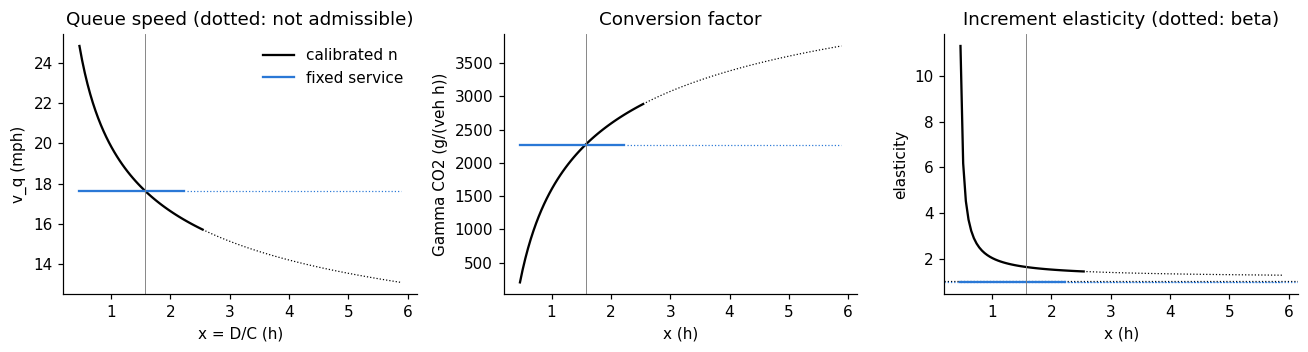

In [3]:
xs = np.linspace(card['x_min_h'], card['x_max_h'], 121)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
for name, c, col in (('calibrated n', card, 'k'), ('fixed service', fixed, '#2a78d6')):
    R = [qvdfe.response(c, x, coef) for x in xs]
    ok = np.array([r['valid'] for r in R])
    for k, key in enumerate(('vq', 'Gamma', 'increment_elasticity')):
        y = np.array([r[key] for r in R], float)
        ax[k].plot(xs, np.where(ok, y, np.nan), color=col, label=name if k == 0 else None)
        ax[k].plot(xs, np.where(ok, np.nan, y), color=col, ls=':', lw=.8)   # dotted: outside the admissible branch
    ax[2].axhline(R[0]['beta'], color=col, ls=':', lw=.8)
for a_ in ax: a_.axvline(x0, color='grey', lw=.6)
ax[0].set(xlabel='x = D/C (h)', ylabel='v_q (mph)', title='Queue speed (dotted: not admissible)'); ax[0].legend(frameon=False)
ax[1].set(xlabel='x (h)', ylabel='Gamma CO2 (g/(veh h))', title='Conversion factor')
ax[2].set(xlabel='x (h)', ylabel='elasticity', title='Increment elasticity (dotted: beta)')
plt.tight_layout()

## 6. Interpretation question
On this card, is $\varepsilon_{\Gamma,x}$ positive or negative, and what does its sign say about whether a delay-based congestion charge would under- or over-state the emission increment caused by an added vehicle?